In [1]:
import os,sys

# Set the path to the parent directory manually
parent_dir = os.path.abspath("../..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
from datetime import datetime
import glob
from netCDF4 import Dataset
from util.wrf_process import (calc_derive, object_tracking, read_and_write, to_polar)
from util.ml_framework import (cnn, vae)
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
import gc,pickle
from tqdm import tqdm
import xarray as xr
from natsort import natsorted
from util.ml_preprocess import data_preproc
#from vae3d import VAEEncoder, VAEDecoder, VAE, elbo_loss, weights_init
import optuna
import random,math
import proplot as plot

/glade/derecho/scratch/ihtam/tmp/ipykernel_15685/1496010805.py:12: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 11.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 9,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_15685/1532609950.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


In [3]:
class calc_diag:
    def __init__(self,WRFFILELIST,trackdata,startindx,preslv,zlv,weshape,nsshape):
        self.WRFFILELIST = WRFFILELIST
        self.trackdata = trackdata
        self.startindx = startindx
        self.preslv = preslv
        self.zlv = zlv
        self.weshape = weshape
        self.nsshape = nsshape

    def interp_to_preslv(self,vartointerp,prestointerp):
        nc_wp = [interplevel(vartointerp,prestointerp,i) for i in self.preslv]
        return np.asarray(nc_wp)

    def interp_to_zlv(self,vartointerp,prestointerp):
        nc_wp = [interplevel(vartointerp,prestointerp,i) for i in self.zlv]
        return np.asarray(nc_wp)
        
    def read_vars(self,varname):
        varout = []
        for i in range(len(self.WRFFILELIST)):
            varout.append(getvar(Dataset(self.WRFFILELIST[i]),varname))
        return np.asarray(varout)

    def read_vars_and_interp(self,varname,TYPE):
        varout = []
        for i in range(len(self.WRFFILELIST)):
            vartointerp = getvar(Dataset(self.WRFFILELIST[i]),varname)
            if TYPE=='pres':
                prestointerp = getvar(Dataset(self.WRFFILELIST[i]),'pres')
                varout.append(self.interp_to_preslv(vartointerp,prestointerp))
            elif TYPE=='height_agl':
                ztointerp = getvar(Dataset(self.WRFFILELIST[i]),'height_agl')
                varout.append(self.interp_to_zlv(vartointerp,ztointerp))
        return np.asarray(varout)
        
    def find_track_ij(self):
        ixs,iys = [],[]
        for i, WRFFILE in tqdm(enumerate(self.WRFFILELIST)):
            # read file
            nc_ctrl = Dataset(WRFFILE)
            # Target location
            target_lat = self.trackdata['clat'][self.startindx+i] # Simulations start from 12 UTC
            target_lon = self.trackdata['clon'][self.startindx+i] # Simulations start from 12 UTC
            # Compute track indices
            ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
            ixs.append(int(ix.values))
            iys.append(int(iy.values))
        return ixs,iys
        
    def compute_tc_shear(self, u, v, x0, y0, dx_km=3.0,
                     inner_km=200.0, outer_km=800.0,
                     p_top=200.0, p_bot=850.0):
        """
        Compute mean 200–850 hPa shear vector in a TC-centered annulus.

        Parameters
        ----------
        ds : netCDF Dataset (opened with netCDF4 or xarray + wrf-python)
            WRF output file handle
        x0, y0 : int
            TC center grid indices (x,y) in WRF domain
        dx_km : float
            Grid spacing (km)
        inner_km, outer_km : float
            Inner and outer radius of annulus (km)
        p_top, p_bot : float
            Top and bottom pressure levels (hPa)

        Returns
        -------
        shear_u, shear_v : floats
            Zonal and meridional shear components (m/s)
        shear_mag : float
            Shear magnitude (m/s)
        """

        # --- Interpolate to levels
        u200 = u[self.preslv.index(p_top),...]
        v200 = v[self.preslv.index(p_top),...]
        u850 = u[self.preslv.index(p_bot),...]
        v850 = v[self.preslv.index(p_bot),...]

        # --- Make distance mask in km
        ny, nx = u200.shape
        X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
        dx = (X - x0) * dx_km
        dy = (Y - y0) * dx_km
        r = np.sqrt(dx**2 + dy**2)

        mask = (r >= inner_km) & (r <= outer_km)

        # --- Area-average wind in annulus
        u200m = np.nanmean(np.where(mask, u200, np.nan))
        v200m = np.nanmean(np.where(mask, v200, np.nan))
        u850m = np.nanmean(np.where(mask, u850, np.nan))
        v850m = np.nanmean(np.where(mask, v850, np.nan))

        # --- Shear vector
        shear_u = u200m - u850m
        shear_v = v200m - v850m
        shear_mag = np.sqrt(shear_u**2 + shear_v**2)

        return shear_u, shear_v, shear_mag

    def get_shear_mag_dir(self,Upres,Vpres,Xs,ys,settings=[200.0,800.0,200.0,850.0,3.0]):
        """
        settings = [inner_km,outer_km,p_top,p_bot,dx_km]
        """
        shear_mags,shear_dirs = [],[]
        shear_us, shear_vs = [],[]
        for i in range(len(Xs)):
            radiusshape = int(settings[1]/settings[4])
            if ((self.weshape-Xs[i])>radiusshape) and ((self.nsshape-ys[i])>radiusshape):
                shear_mags.append(np.nan)
                shear_dirs.append(np.nan)
                shear_us.append(np.nan)
                shear_vs.append(np.nan)
            else:
                shear_u, shear_v, shear_mag = self.compute_tc_shear(Upres[i,...], Vpres[i,...], Xs[i], ys[i], 
                                                                       dx_km=settings[4],
                                                                       inner_km=settings[0], outer_km=settings[1],
                                                                       p_top=settings[2], p_bot=settings[3])
                shear_mags.append(shear_mag)
                shear_dirs.append((np.degrees(np.arctan2(shear_v, shear_u)) % 360.0))
                shear_us.append(shear_u)
                shear_vs.append(shear_v)
        return shear_mags,shear_dirs, shear_vs, shear_us

    def data_to_TCcentre(self,data,Xs,ys,settings=[800.0,3.0,200.0]):
        dataTC = []
        for i in range(len(Xs)):
            radiusshape = int(settings[0]/settings[1])
            if ((self.weshape-Xs[i])>radiusshape) and ((self.nsshape-ys[i])>radiusshape):
                dataTC.append(np.nan)
            else:
                domainint = int(settings[2])
                dataTC.append(data[i,:,ys[i]-domainint:ys[i]+domainint,Xs[i]-domainint:Xs[i]+domainint])
        return np.asarray(dataTC)
            
    def data_to_polar(self,Cnc_wpz,dx,rmax,dr,nazim):        
        # Convert to polar coordinates
        # Suppose Xtrain_n shape = (n_samples, 9, ny, nx)
        ny, nx = Cnc_wpz.shape[-2:]
        if len(Cnc_wpz.shape)>3:
            tri, pts, target_points, r, az = to_polar.precompute_cartesian_to_polar_map(
                nx=nx, ny=ny, dx=dx, rmax=rmax, dr=dr, nazim=nazim
            )
            return to_polar.fast_cartesian_to_polar_batch(Cnc_wpz, tri, pts, target_points, r, az), r, az
        elif len(Cnc_wpz.shape)==3:
            Cnc_wpza = np.expand_dims(Cnc_wpz, axis=1)
            tri, pts, target_points, r, az = to_polar.precompute_cartesian_to_polar_map(
                nx=nx, ny=ny, dx=dx, rmax=rmax, dr=dr, nazim=nazim
            )
            return to_polar.fast_cartesian_to_polar_batch(Cnc_wpza, tri, pts, target_points, r, az), r, az

In [4]:
def get_proc_data_polar(track,ctrl_files,wantvar='rh',TYPE='height_agl'):    
    etalevels,weshape,nsshape = getvar(Dataset(ctrl_files[0]),'pres').shape
    wrfdiags = calc_diag(ctrl_files,track_memb03,12,[10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000],
                         [500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000],
                         weshape,nsshape)
    tracks_ij = wrfdiags.find_track_ij()

    # Shear calculation
    Upres,Vpres = wrfdiags.read_vars_and_interp('ua','pres'), wrfdiags.read_vars_and_interp('va','pres')

    shear_mags,shear_dirs,shear_uv,shear_vs = wrfdiags.get_shear_mag_dir(Upres,Vpres,tracks_ij[0],
                                                                         tracks_ij[1],
                                                                         settings=[200.0,800.0,int(200.0*100),int(850.0*100),3.0])
    # Calculate polar version of one variable
    RHpres = wrfdiags.read_vars_and_interp(wantvar,TYPE)
    RHpres_ctre = wrfdiags.data_to_TCcentre(RHpres,tracks_ij[0],tracks_ij[1])
    RHpres_plr, r, az = wrfdiags.data_to_polar(RHpres_ctre,3,600,3,360)
    return {'trackkij':tracks_ij,'shearmags':shear_mags,'sheardirs':shear_dirs,'varcart':RHpres_ctre,'varpol':RHpres_plr, 'r':r, 'az':az}

def save_to_pickle(filepath,data):
    with open(filepath, 'wb') as handle:
        pickle.dump(data, handle)

def open_pickle(filepath):
    with open(filepath, 'rb') as handle:
        data = pickle.load(handle)
    return data

In [5]:
# Track path
track_memb03 = xr.open_dataset('/glade/work/ihtam/storage/track_avor_850-600.nc')

ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan_perturb/ctrl/wrfout_d02_2013-11-0*"))[:24] #sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))[:6]
miaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2idealaxi/wrfout_d02_2013-11-0*"))[:24]
aiaxi2x_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan_perturb/add_2IDEAL/wrfout_d02_2013-11-0*"))[:24] #sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/add_2idealaxi/wrfout_d02_2013-11-0*"))[:6]
mdd_p2f_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:24]
dd_p2f_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan_perturb/add_2ML_pp2/wrfout_d02_2013-11-0*"))[:24] #sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:6] 

## Calculate VMF

In [6]:
import numpy as np

# =============================================================================
# PV Budget Class — Corrected + Memory Optimised
# Coordinate order: [time, z, radius, azimuth]
# w (wa) is in m/s, z is AGL height in metres
#
# Key memory strategy:
#   - Vorticity (xi_r, xi_az, xi_z) computed ONCE per experiment via
#     _compute_vorticity() and reused for PV, advection, and all diabatic terms
#   - Intermediates deleted with `del` immediately after use
#   - np.gradient results consumed in-place where possible
#   - clean_inf done in-place (no copy)
# =============================================================================

class pv_budget:
    def __init__(self, pres, z, track, exps, expname):
        self.pres    = pres       # Pressure levels
        self.z       = z          # AGL Height levels [m]
        self.track   = track      # TC track
        self.exps    = exps       # List storing experiment filenames
        self.expname = expname    # Name of experiments

    # ── inf cleaner (in-place, no copy) ──────────────────────────────────────
    @staticmethod
    def clean_inf(arr):
        """Replace +-inf with nan in-place. Returns arr."""
        arr[np.isinf(arr)] = np.nan
        return arr

    # ── unchanged utility methods ─────────────────────────────────────────────
    def proc_onevar(self, wantvar, TYPE):
        vardict = {}
        for expname, expfilelist in zip(self.expname, self.exps):
            vardict[expname] = get_proc_data_polar(self.track, expfilelist,
                                                   wantvar=wantvar, TYPE=TYPE)
        return vardict

    def rotating_polar_onevar(self, vardict, sheardict):
        rotated_vardict = {}
        for expnamez in self.expname:
            if type(vardict[expnamez]) == np.ndarray:
                temp = vardict[expnamez]
            else:
                temp = vardict[expnamez]['varpol']
            sheardir = sheardict[expnamez]['sheardirs']
            rotatemp = np.asarray([np.roll(temp[i], shift=-int(sheardir[i]), axis=-1)
                                   for i in range(len(temp))])
            rotated_vardict[expnamez] = rotatemp
        return rotated_vardict

    def calc_den(self, tkdict, qvdict, presdict):
        dendict = {}
        for expnamez in self.expname:
            dendict[expnamez] = proc_vars.density_moist(
                tkdict[expnamez]['varpol'],
                qvdict[expnamez]['varpol'],
                presdict[expnamez]['varpol']
            )
        return dendict

    def get_vr_vt(self, uadict, vadict):
        vrdict, vtdict = {}, {}
        for expnamez in self.expname:
            theta  = np.deg2rad(uadict[expnamez]['az'])
            cos_th = np.cos(theta)[None, None, None, :]
            sin_th = np.sin(theta)[None, None, None, :]
            vrdict[expnamez] = ( uadict[expnamez]['varpol'] * cos_th
                               + vadict[expnamez]['varpol'] * sin_th)
            vtdict[expnamez] = (-uadict[expnamez]['varpol'] * sin_th
                               + vadict[expnamez]['varpol'] * cos_th)
        return vrdict, vtdict

    def reg_vars(self, tk, qv, pres, den, vr, vt, wa, theta,
                 RTHRATLW, RTHRATSW, H_DIABATIC):
        self.tk         = tk
        self.qv         = qv
        self.pres       = pres
        self.den        = den
        self.vr         = vr
        self.vt         = vt
        self.wa         = wa
        self.theta      = theta
        self.RTHRATLW   = RTHRATLW
        self.RTHRATSW   = RTHRATSW
        self.H_DIABATIC = H_DIABATIC

    # ── gradient operator ─────────────────────────────────────────────────────
    def gradient(self, var, r, az):
        """
        Returns (dvar/dr, (1/r)*dvar/daz, dvar/dz).
        var: [t, z, r, az]; r on axis=2, az on axis=3.
        (1/r) division done in-place — no extra copy.
        """
        dvardr  = np.gradient(var, r,      axis=2)
        dvardaz = np.gradient(var, az,     axis=3)
        dvardaz /= r.reshape(1, 1, -1, 1)   # in-place, no copy
        dvardz  = np.gradient(var, self.z, axis=1)
        return dvardr, dvardaz, dvardz

    # ── vorticity — computed ONCE per experiment, reused everywhere ───────────
    def _compute_vorticity(self, vr, vt, w, r, az, f):
        """
        Absolute vorticity components in cylindrical (r, az, z):
          xi_z  = (1/r)*d(r*vt)/dr - (1/r)*dvr/daz + f
          xi_r  = (1/r)*dw/daz - dvt/dz
          xi_az = dvr/dz - dw/dr

        Intermediates deleted immediately after use.
        Returns xi_r, xi_az, xi_z  [t, z, r, az].
        """
        r4d = r.reshape(1, 1, -1, 1)

        # xi_z
        rvt      = r4d * vt
        d_rvt_dr = np.gradient(rvt, r,  axis=2); del rvt
        dvr_daz  = np.gradient(vr,  az, axis=3)
        xi_z     = (d_rvt_dr - dvr_daz) / r4d + f
        del d_rvt_dr, dvr_daz

        # xi_r
        dw_daz = np.gradient(w,  az,     axis=3)
        dvt_dz = np.gradient(vt, self.z, axis=1)
        xi_r   = dw_daz / r4d - dvt_dz
        del dw_daz, dvt_dz

        # xi_az
        dvr_dz = np.gradient(vr, self.z, axis=1)
        dw_dr  = np.gradient(w,  r,      axis=2)
        xi_az  = dvr_dz - dw_dr
        del dvr_dz, dw_dr

        return xi_r, xi_az, xi_z

    # ── main budget ───────────────────────────────────────────────────────────
    def calc_pvbudget(self, uadict):
        """
        Full PV budget in PVU/s. Vorticity computed once per experiment.

        Budget:
          dq/dt = -(vr*dq/dr + vt*(1/r)*dq/daz + w*dq/dz)
                  + S_lw + S_sw + S_micro
                  + Residual  (friction + numerical diffusion)
        """
        pvtermsdict = {}

        for expnamez in self.expname:
            print(f"Processing {expnamez}...")
            r   = uadict[expnamez]['r'] * 1000        # km -> m
            az  = np.deg2rad(uadict[expnamez]['az'])  # deg -> rad
            r4d = r.reshape(1, 1, -1, 1)

            vr  = self.vr[expnamez]
            vt  = self.vt[expnamez]
            w   = self.wa[expnamez]
            den = self.den[expnamez]
            f   = 10e-5

            # ── Step 1: vorticity (computed ONCE, ~400 MB peak) ───────────────
            print("  Vorticity...")
            xi_r, xi_az, xi_z = self._compute_vorticity(vr, vt, w, r, az, f)

            # ── Step 2: full Ertel PV ─────────────────────────────────────────
            print("  Full Ertel PV...")
            dth_dr, dth_daz, dth_dz = self.gradient(self.theta[expnamez], r, az)

            pv  = xi_r  * dth_dr;  del dth_dr   # accumulate dot product
            pv += xi_az * dth_daz; del dth_daz  # in-place to avoid temp array
            pv += xi_z  * dth_dz;  del dth_dz
            pv /= den
            pv *= 1e6                            # PVU

            pvterms = {}

            # ── Step 3: storage ───────────────────────────────────────────────
            pvterms['dpvo'] = self.clean_inf(np.gradient(pv, 3600.0, axis=0))

            # ── Step 4: advection ─────────────────────────────────────────────
            print("  Advection...")
            dpv_dr, dpv_daz, dpv_dz = self.gradient(pv, r, az)
            del pv  # free after gradients are taken

            pvterms['vradv'] = self.clean_inf(-vr * dpv_dr);  del dpv_dr
            pvterms['vtadv'] = self.clean_inf(-vt * dpv_daz); del dpv_daz
            pvterms['wadv']  = self.clean_inf(-w  * dpv_dz);  del dpv_dz

            # ── Step 5: diabatic sources (one variable at a time) ─────────────
            # Peak memory here: 3 xi arrays + 3 gradient arrays = ~800 MB
            for tag, dthdt in [('lw', self.RTHRATLW[expnamez]),
                                ('sw', self.RTHRATSW[expnamez]),
                                ('la', self.H_DIABATIC[expnamez])]:
                print(f"  Diabatic source: {tag}...")
                dQ_dr, dQ_daz, dQ_dz = self.gradient(dthdt, r, az)

                pvterms[f'{tag}_pv_r']  = self.clean_inf(
                    (xi_r  / den) * dQ_dr  * 1e6); del dQ_dr
                pvterms[f'{tag}_pv_az'] = self.clean_inf(
                    (xi_az / den) * dQ_daz * 1e6); del dQ_daz
                pvterms[f'{tag}_pv_z']  = self.clean_inf(
                    (xi_z  / den) * dQ_dz  * 1e6); del dQ_dz

            del xi_r, xi_az, xi_z  # free vorticity after all diabatic terms done

            # ── Step 6: residual ──────────────────────────────────────────────
            rhs = (pvterms['vradv']    + pvterms['vtadv']    + pvterms['wadv']
                 + pvterms['lw_pv_r']  + pvterms['lw_pv_az'] + pvterms['lw_pv_z']
                 + pvterms['sw_pv_r']  + pvterms['sw_pv_az'] + pvterms['sw_pv_z']
                 + pvterms['la_pv_r']  + pvterms['la_pv_az'] + pvterms['la_pv_z'])
            pvterms['residual'] = self.clean_inf(pvterms['dpvo'] - rhs)
            del rhs

            pvtermsdict[expnamez] = pvterms
            print(f"  Done.")

        return pvtermsdict

In [7]:
import proc_vars
pres = np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])
z = np.array([500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000])
pv_init = pv_budget(pres, z, track_memb03, [ctrl_files,aiaxi2x_files,dd_p2f_files], ['CTRL','AIAXI2X','DD_P2F'])

In [8]:
tk_dict = open_pickle('./parallel/store/tk_dict_z.pkl')
tk_dict_rotated = pv_init.rotating_polar_onevar(tk_dict,tk_dict)
theta_dict = open_pickle('./parallel/store/theta_dict_z.pkl')
theta_dict_rotated = pv_init.rotating_polar_onevar(theta_dict,tk_dict)
qv_dict = open_pickle('./parallel/store/QVAPOR_dict_z.pkl')
qv_dict_rotated = pv_init.rotating_polar_onevar(qv_dict,tk_dict)
pres_dict = open_pickle('./parallel/store/pres_dict_z.pkl')
pres_dict_rotated = pv_init.rotating_polar_onevar(pres_dict,tk_dict)
den_dict = pv_init.calc_den(tk_dict,qv_dict,pres_dict)
den_dict_rotated = pv_init.rotating_polar_onevar(den_dict,tk_dict)
wa_dict = open_pickle('./parallel/store/wa_dict_z.pkl')
wa_dict_rotated = pv_init.rotating_polar_onevar(wa_dict,tk_dict)
RTHRATLW_dict = open_pickle('./parallel/store/RTHRATLW_dict_z.pkl')
RTHRATLW_dict_rotated = pv_init.rotating_polar_onevar(RTHRATLW_dict,tk_dict)
RTHRATSW_dict = open_pickle('./parallel/store/RTHRATSW_dict_z.pkl')
RTHRATSW_dict_rotated = pv_init.rotating_polar_onevar(RTHRATSW_dict,tk_dict)

del qv_dict,pres_dict,den_dict,wa_dict,RTHRATLW_dict,RTHRATSW_dict,theta_dict
gc.collect()

82

In [9]:
ua_dict = open_pickle('./parallel/store/ua_dict_z.pkl')
ua_dict_rotated = pv_init.rotating_polar_onevar(ua_dict,tk_dict)
va_dict = open_pickle('./parallel/store/va_dict_z.pkl')
va_dict_rotated = pv_init.rotating_polar_onevar(va_dict,tk_dict)
#pvo_dict = open_pickle('./parallel/store/pvo_dict_z.pkl')
#pvo_dict_rotated = pv_init.rotating_polar_onevar(pvo_dict,tk_dict)
H_DIABATIC_dict = open_pickle('./store/H_DIABATIC_dict_z.pkl')
H_DIABATIC_dict_rotated = pv_init.rotating_polar_onevar(H_DIABATIC_dict,tk_dict)

del H_DIABATIC_dict
gc.collect()

0

In [10]:
vr_dict, vt_dict = pv_init.get_vr_vt(ua_dict,va_dict)
vr_dict_rotated = pv_init.rotating_polar_onevar(vr_dict,tk_dict)
vt_dict_rotated = pv_init.rotating_polar_onevar(vt_dict,tk_dict)

In [11]:
pv_init.reg_vars(tk_dict_rotated,qv_dict_rotated,pres_dict_rotated,
                 den_dict_rotated,
                 vr_dict_rotated,vt_dict_rotated,wa_dict_rotated,theta_dict_rotated,
                 RTHRATLW_dict_rotated,RTHRATSW_dict_rotated,H_DIABATIC_dict_rotated)

del tk_dict_rotated,qv_dict_rotated,pres_dict_rotated,den_dict_rotated,vr_dict_rotated,vt_dict_rotated,wa_dict_rotated,theta_dict_rotated,
RTHRATLW_dict_rotated,RTHRATSW_dict_rotated,H_DIABATIC_dict_rotated,ua_dict,va_dict,ua_dict_rotated,va_dict_rotated,tk_dict
gc.collect()

0

In [12]:
pvbudget_results = pv_init.calc_pvbudget(ua_dict)

Processing CTRL...
  Vorticity...


/glade/derecho/scratch/ihtam/tmp/ipykernel_15685/2518546385.py:118: RuntimeWarning: divide by zero encountered in divide
  xi_z     = (d_rvt_dr - dvr_daz) / r4d + f
/glade/derecho/scratch/ihtam/tmp/ipykernel_15685/2518546385.py:124: RuntimeWarning: divide by zero encountered in divide
  xi_r   = dw_daz / r4d - dvt_dz
/glade/derecho/scratch/ihtam/tmp/ipykernel_15685/2518546385.py:124: RuntimeWarning: invalid value encountered in divide
  xi_r   = dw_daz / r4d - dvt_dz


  Full Ertel PV...


/glade/derecho/scratch/ihtam/tmp/ipykernel_15685/2518546385.py:97: RuntimeWarning: divide by zero encountered in divide
  dvardaz /= r.reshape(1, 1, -1, 1)   # in-place, no copy
/glade/derecho/scratch/ihtam/tmp/ipykernel_15685/2518546385.py:97: RuntimeWarning: invalid value encountered in divide
  dvardaz /= r.reshape(1, 1, -1, 1)   # in-place, no copy
/glade/derecho/scratch/ihtam/tmp/ipykernel_15685/2518546385.py:167: RuntimeWarning: invalid value encountered in multiply
  pv  = xi_r  * dth_dr;  del dth_dr   # accumulate dot product
/glade/derecho/scratch/ihtam/tmp/ipykernel_15685/2518546385.py:168: RuntimeWarning: invalid value encountered in add
  pv += xi_az * dth_daz; del dth_daz  # in-place to avoid temp array
/glade/derecho/scratch/ihtam/tmp/ipykernel_15685/2518546385.py:169: RuntimeWarning: invalid value encountered in add
  pv += xi_z  * dth_dz;  del dth_dz
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: inva

  Advection...


/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/numpy/lib/function_base.py:1248: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


  Diabatic source: lw...
  Diabatic source: sw...


/glade/derecho/scratch/ihtam/tmp/ipykernel_15685/2518546385.py:196: RuntimeWarning: invalid value encountered in multiply
  (xi_r  / den) * dQ_dr  * 1e6); del dQ_dr
/glade/derecho/scratch/ihtam/tmp/ipykernel_15685/2518546385.py:200: RuntimeWarning: invalid value encountered in multiply
  (xi_z  / den) * dQ_dz  * 1e6); del dQ_dz


  Diabatic source: la...
  Done.
Processing AIAXI2X...
  Vorticity...
  Full Ertel PV...
  Advection...
  Diabatic source: lw...
  Diabatic source: sw...
  Diabatic source: la...
  Done.
Processing DD_P2F...
  Vorticity...
  Full Ertel PV...
  Advection...
  Diabatic source: lw...
  Diabatic source: sw...
  Diabatic source: la...
  Done.


## Profile

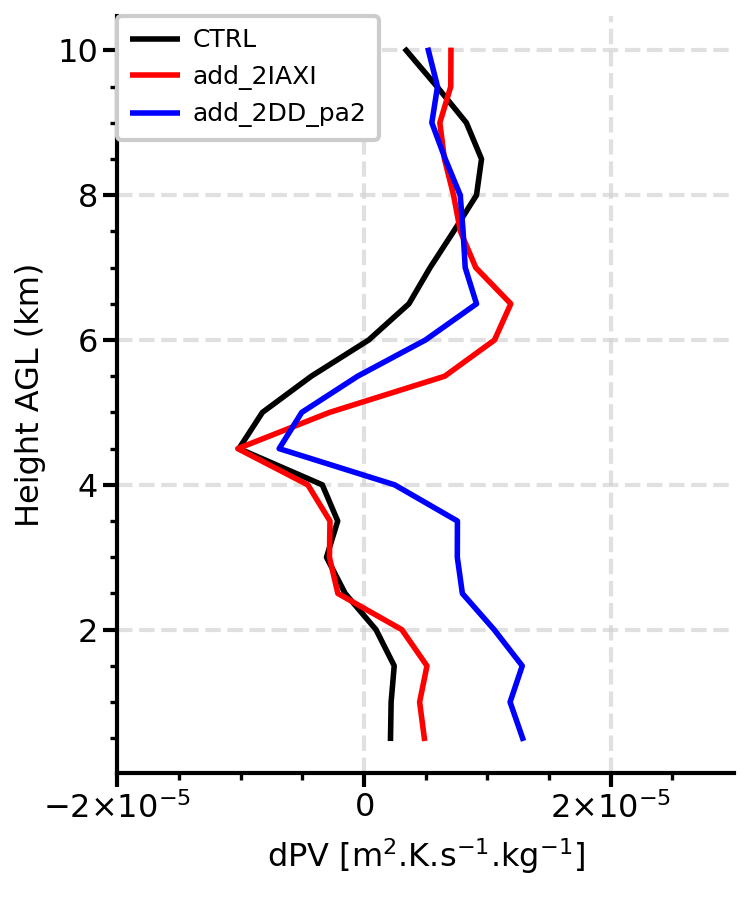

In [19]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(3.75,4.5), share=True)
am = axs[0].plot(np.nanmean(pvbudget_results['CTRL']['dpvo'][:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(pvbudget_results['AIAXI2X']['dpvo'][:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, c='r', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(pvbudget_results['DD_P2F']['dpvo'][:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, c='b', lw=2, label='add_2DD_pa2')
axs[0].legend(ncols=1,loc=1)
axs.format(#ylim=(1000,100),
    xlim=(-2e-5,3e-5),
           xlabel='dPV [m$^2$.K.s$^{-1}$.kg$^{-1}$]', ylabel='Height AGL (km)',
xlocator=(-2e-5,0,2e-5),xformatter='sci')
plt.savefig('./pics/pvbud_dPV_memb03.png',dpi=400)
plt.show()

In [206]:
HIHIHI = np.nanmean(pvbudget_results['CTRL']['vradv'][:-1,:,:,:],axis=(0,2,3))/1e-6+\
np.nanmean(pvbudget_results['CTRL']['wadv'][:-1,:,:,:],axis=(0,2,3))/1e-6+\
np.nanmean(pvbudget_results['CTRL']['lw_pv_z'][:-1,:,:,:],axis=(0,2,3))/1e-6+\
np.nanmean(pvbudget_results['CTRL']['sw_pv_z'][:-1,:,:,:],axis=(0,2,3))/1e-6+\
np.nanmean(pvbudget_results['CTRL']['la_pv_z'][:-1,:,:,:],axis=(0,2,3))/1e-6+\
np.nanmean(np.nan_to_num(pvbudget_results['AIAXI2X']['vtadv'], neginf=0,posinf=0)[:-1,:,:,:],axis=(0,2,3))/1e-6

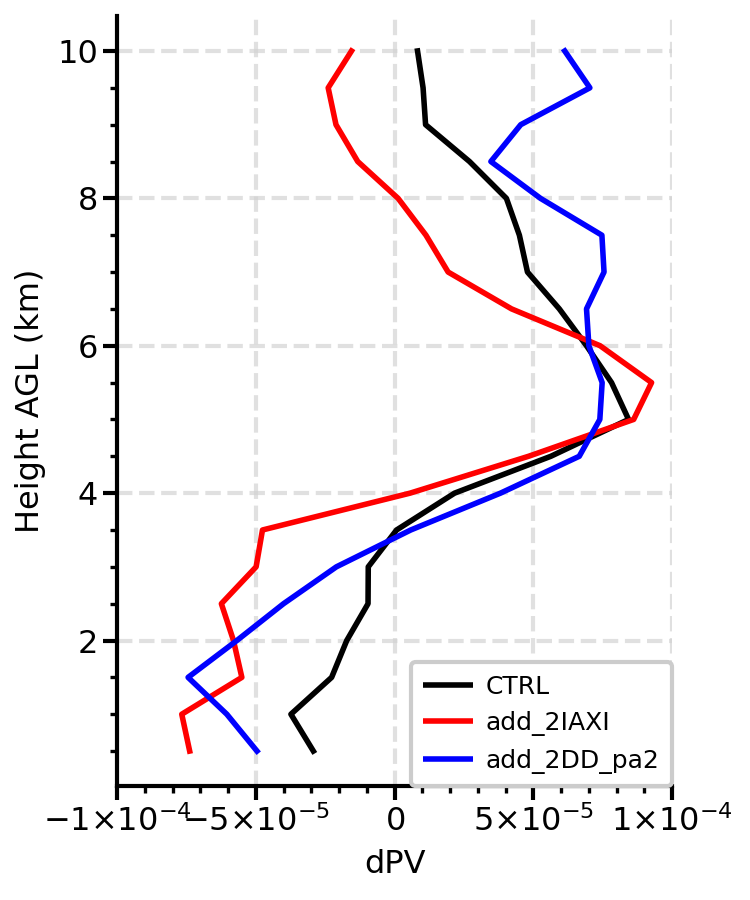

In [48]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(3.75,4.5), share=True)
am = axs[0].plot(np.nanmean(pvbudget_results['CTRL']['vradv'][10:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(pvbudget_results['AIAXI2X']['vradv'][10:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, c='r', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(pvbudget_results['DD_P2F']['vradv'][10:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, c='b', lw=2, label='add_2DD_pa2')
axs[0].legend(ncols=1,loc=1)
axs.format(#ylim=(1000,100),
    xlim=(-10e-5,10e-5),
           xlabel='dPV', ylabel='Height AGL (km)',xformatter='sci')
#plt.savefig('./pics/vmf_memb3_cfad.png',dpi=400)
plt.show()

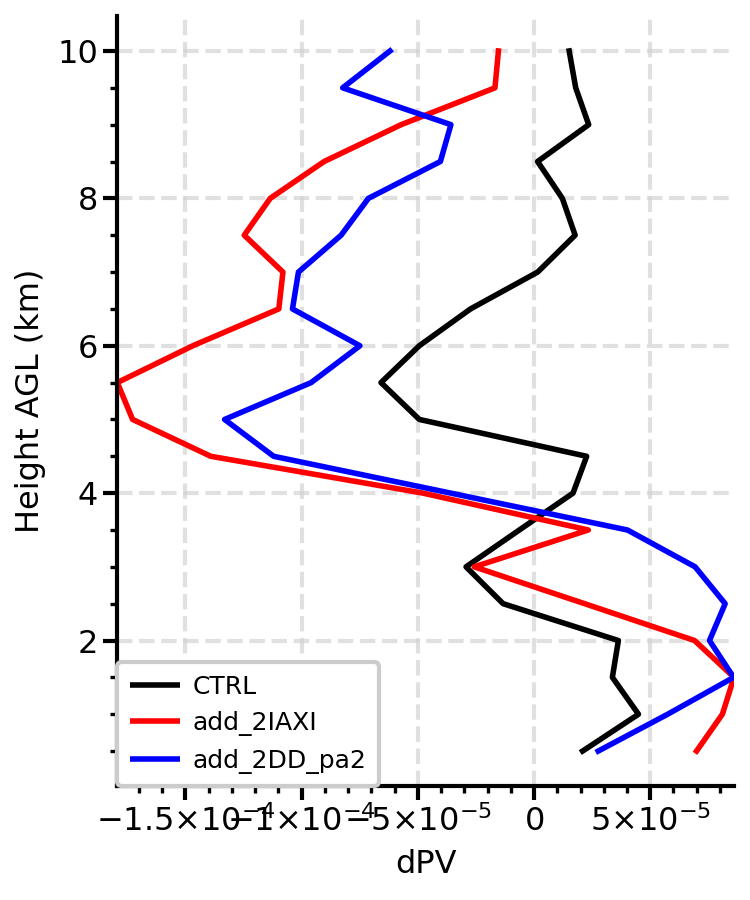

In [45]:
ig, axs = plot.subplots(ncols=1, nrows=1, figsize=(3.75,4.5), share=True)
am = axs[0].plot(np.nanmean(np.nan_to_num(pvbudget_results['CTRL']['vtadv'], neginf=0,posinf=0)[10:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, 
                 c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(np.nan_to_num(pvbudget_results['AIAXI2X']['vtadv'], neginf=0,posinf=0)[10:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, 
                 c='r', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(np.nan_to_num(pvbudget_results['DD_P2F']['vtadv'], neginf=0,posinf=0)[10:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, 
                 c='b', lw=2, label='add_2DD_pa2')
axs[0].legend(ncols=1,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='dPV', ylabel='Height AGL (km)',
xformatter='sci')
#plt.savefig('./pics/vmf_memb3_cfad.png',dpi=400)
plt.show()

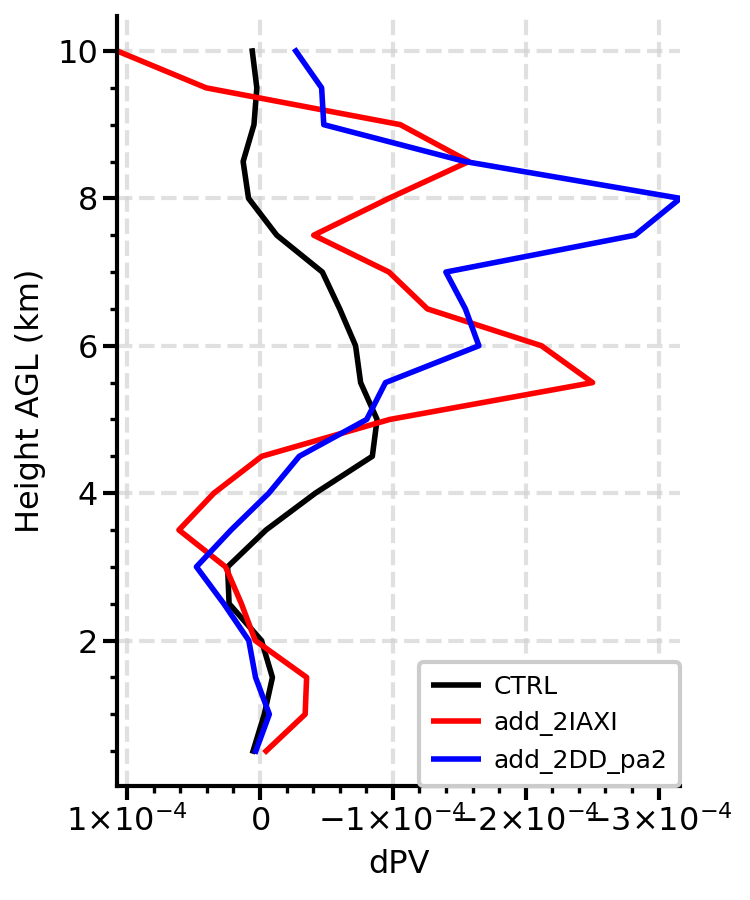

In [44]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(3.75,4.5), share=True)
am = axs[0].plot(np.nanmean(pvbudget_results['CTRL']['wadv'][10:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(pvbudget_results['AIAXI2X']['wadv'][10:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, c='r', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(pvbudget_results['DD_P2F']['wadv'][10:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, c='b', lw=2, label='add_2DD_pa2')
axs[0].legend(ncols=1,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='dPV', ylabel='Height AGL (km)',xformatter='sci')
#plt.savefig('./pics/vmf_memb3_cfad.png',dpi=400)
plt.show()

In [14]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(3.75,4.5), share=True)
am = axs[0].plot(np.nanmean(pvbudget_results['CTRL']['lw_pv_z'][:,:12,:33,:],axis=(0,2,3))/1e-6,z[:12]/1000, 
                 c='k', lw=2.5, label='CTRL')
am = axs[0].plot(np.nanmean(pvbudget_results['AIAXI2X']['lw_pv_z'][:,:12,:33,:],axis=(0,2,3))/1e-6,z[:12]/1000, 
                 c='b', lw=2.5, label='add_2IAXI')
am = axs[0].plot(np.nanmean(pvbudget_results['DD_P2F']['lw_pv_z'][:,:12,:33,:],axis=(0,2,3))/1e-6,z[:12]/1000, 
                 c='r', lw=2.5, label='add_2DD_pa2')
axs[0].legend(ncols=1,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='LW PV generation [m$^2$.K.s$^{-1}$.kg$^{-1}$]', ylabel='Height AGL (km)',
xlocator=(-2e-6,0,2e-6,4e-6),xformatter='sci')
plt.savefig('./pics/pvbud_lwprod_memb03_a2.png',dpi=400)
plt.show()

array([  500,  1000,  1500,  2000,  2500,  3000,  3500,  4000,  4500,
        5000,  5500,  6000,  6500,  7000,  7500,  8000,  8500,  9000,
        9500, 10000])

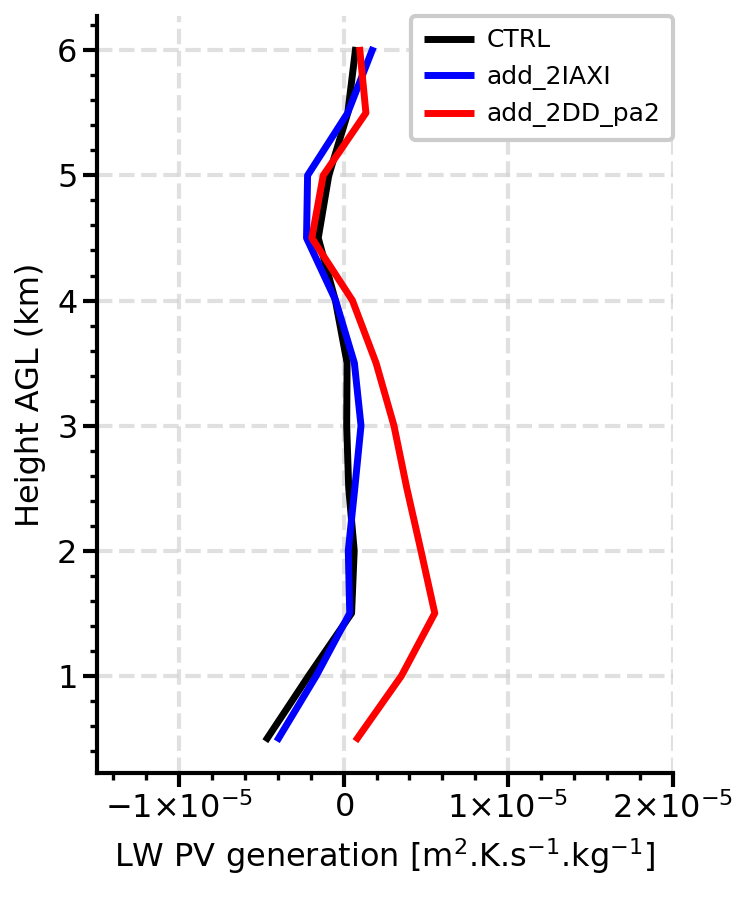

In [23]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(3.75,4.5), share=True)
am = axs[0].plot(np.nanmean(pvbudget_results['CTRL']['lw_pv_z'][:,:12,:33,:],axis=(0,2,3)),z[:12]/1000, 
                 c='k', lw=2.5, label='CTRL')
am = axs[0].plot(np.nanmean(pvbudget_results['AIAXI2X']['lw_pv_z'][:,:12,:33,:],axis=(0,2,3)),z[:12]/1000, 
                 c='b', lw=2.5, label='add_2IAXI')
am = axs[0].plot(np.nanmean(pvbudget_results['DD_P2F']['lw_pv_z'][:,:12,:33,:],axis=(0,2,3)),z[:12]/1000, 
                 c='r', lw=2.5, label='add_2DD_pa2')
axs[0].legend(ncols=1,loc=1)
axs.format(xlim=(-15e-6,20e-6),xformatter='sci',
           xlabel='LW PV generation [m$^2$.K.s$^{-1}$.kg$^{-1}$]', ylabel='Height AGL (km)',)
#xlocator=(-2e-6,0,2e-6,4e-6),xformatter='sci')
#plt.savefig('./pics/pvbud_lwprod_memb03_a2.png',dpi=400)
plt.show()

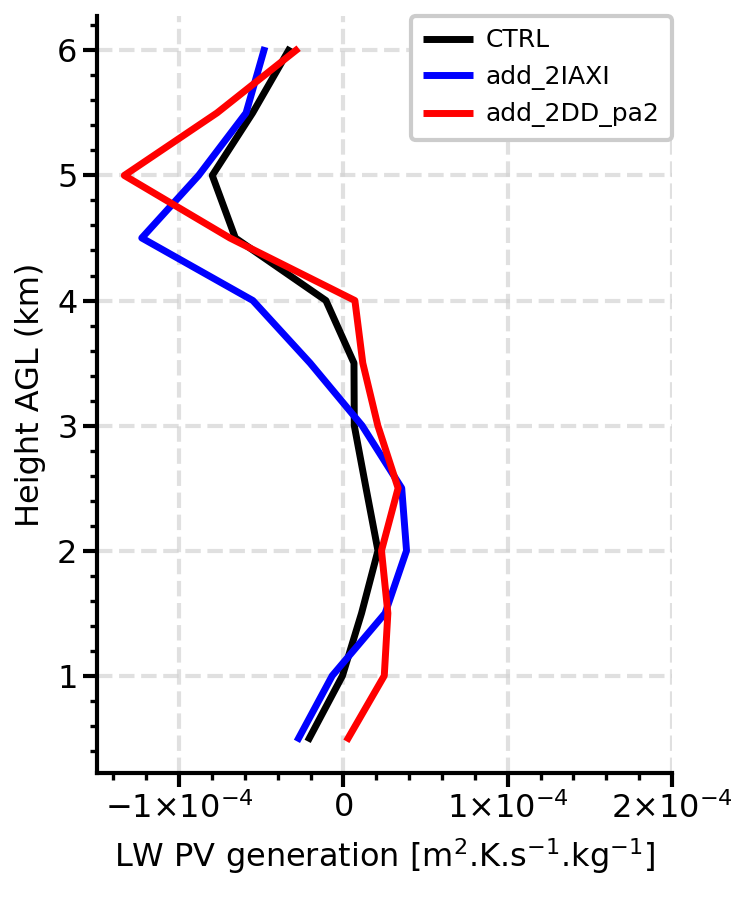

In [27]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(3.75,4.5), share=True)
am = axs[0].plot(np.nanmean(pvbudget_results['CTRL']['residual'][:,:12,:33,:],axis=(0,2,3)),z[:12]/1000, 
                 c='k', lw=2.5, label='CTRL')
am = axs[0].plot(np.nanmean(pvbudget_results['AIAXI2X']['residual'][:,:12,:33,:],axis=(0,2,3)),z[:12]/1000, 
                 c='b', lw=2.5, label='add_2IAXI')
am = axs[0].plot(np.nanmean(pvbudget_results['DD_P2F']['residual'][:,:12,:33,:],axis=(0,2,3)),z[:12]/1000, 
                 c='r', lw=2.5, label='add_2DD_pa2')
axs[0].legend(ncols=1,loc=1)
axs.format(xlim=(-15e-5,20e-5),xformatter='sci',
           xlabel='LW PV generation [m$^2$.K.s$^{-1}$.kg$^{-1}$]', ylabel='Height AGL (km)',)
#xlocator=(-2e-6,0,2e-6,4e-6),xformatter='sci')
#plt.savefig('./pics/pvbud_lwprod_memb03_a2.png',dpi=400)
plt.show()

In [30]:
terms = ['dpvo', 'vradv', 'vtadv', 'wadv', 
         'lw_pv_z', 'sw_pv_z', 'la_pv_z', 'residual']

for term in terms:
    profile = np.nanmean(pvbudget_results['CTRL'][term], axis=(0, 2, 3))  # mean over t, r, az
    print(f"{term:12s}: {profile}")

dpvo        : [ 1.32561021e-06  1.33055438e-06  1.44542812e-06  9.48762963e-07
  9.32787357e-08 -3.80120025e-07  1.42291870e-07 -1.75372217e-08
 -1.46427390e-06 -5.94842216e-07 -5.84730549e-08 -2.73257788e-07
 -8.95256121e-08  3.18609366e-07  6.58497085e-07  1.14747539e-06
  1.56615918e-06  1.37187409e-06  6.60968866e-07  3.05978204e-08]
vradv       : [-9.07448294e-06 -1.91255790e-06 -5.22078192e-07 -7.16459341e-07
 -2.59076484e-06 -4.93504271e-06 -1.87051119e-06  2.07451876e-06
  2.25054093e-06 -3.41209244e-06 -6.34348549e-06 -1.17869308e-05
 -1.44303722e-05 -1.58087922e-05 -1.67857451e-05 -1.23106690e-05
 -7.92753036e-06 -4.33055146e-06 -3.58773559e-06 -2.28572883e-06]
vtadv       : [-8.95261651e-06 -1.01376216e-05 -8.01793139e-06 -7.41541854e-06
 -1.81212222e-06  4.71293736e-06  2.77697781e-06  3.84818079e-06
  1.06977086e-05  2.26833977e-05  2.31428628e-05  2.12924859e-05
  1.97866556e-05  1.67161736e-05  1.67417418e-05  1.53241251e-05
  1.25842031e-05  6.66700784e-06  5.68869476e-

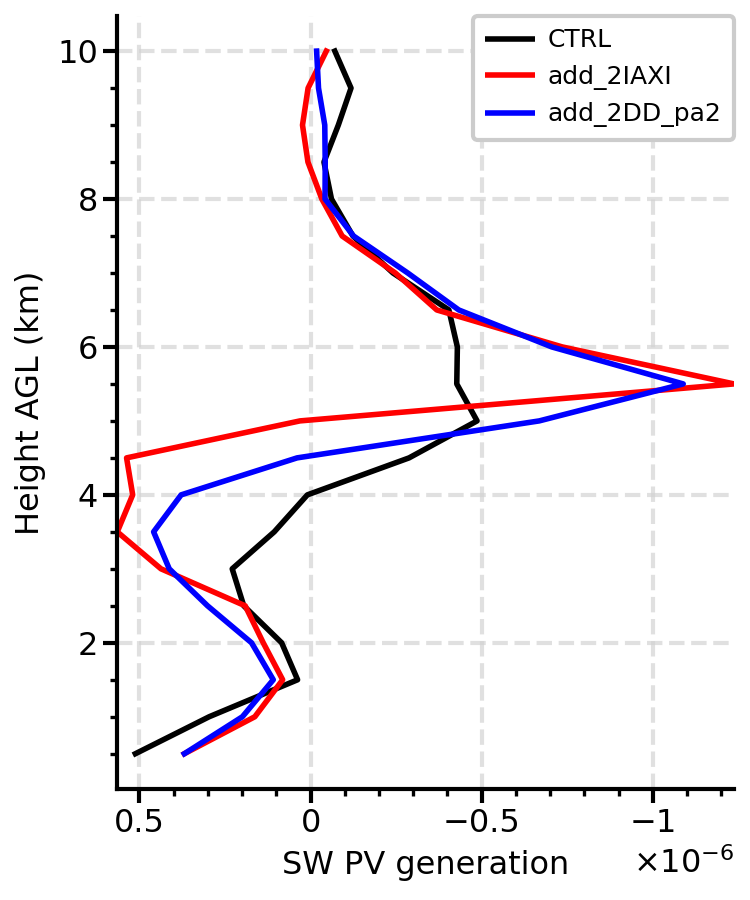

In [34]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(3.75,4.5), share=True)
am = axs[0].plot(np.nanmean(pvbudget_results['CTRL']['sw_pv_z'][:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(pvbudget_results['AIAXI2X']['sw_pv_z'][:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, c='r', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(pvbudget_results['DD_P2F']['sw_pv_z'][:,:,:33,:],axis=(0,2,3))/1e-6,z/1000, c='b', lw=2, label='add_2DD_pa2')
axs[0].legend(ncols=1,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='SW PV generation', ylabel='Height AGL (km)',)
#xlocator=(-2e-6,0,2e-6,4e-6),xformatter='sci')
#plt.savefig('./pics/vmf_memb3_cfad.png',dpi=400)
plt.show()

In [19]:
np.nanmean(pvbudget_results['CTRL']['la_pv_z'][:,:12,:33,:],axis=(0,2,3))

array([ 1.20264978e-04,  7.71122259e-05,  4.16732746e-05,  3.20498743e-05,
        1.64348448e-05,  1.05743379e-05,  3.08141154e-06, -3.24259915e-05,
       -3.74983449e-05, -3.13227082e-05, -2.78708144e-05, -2.07740622e-05])

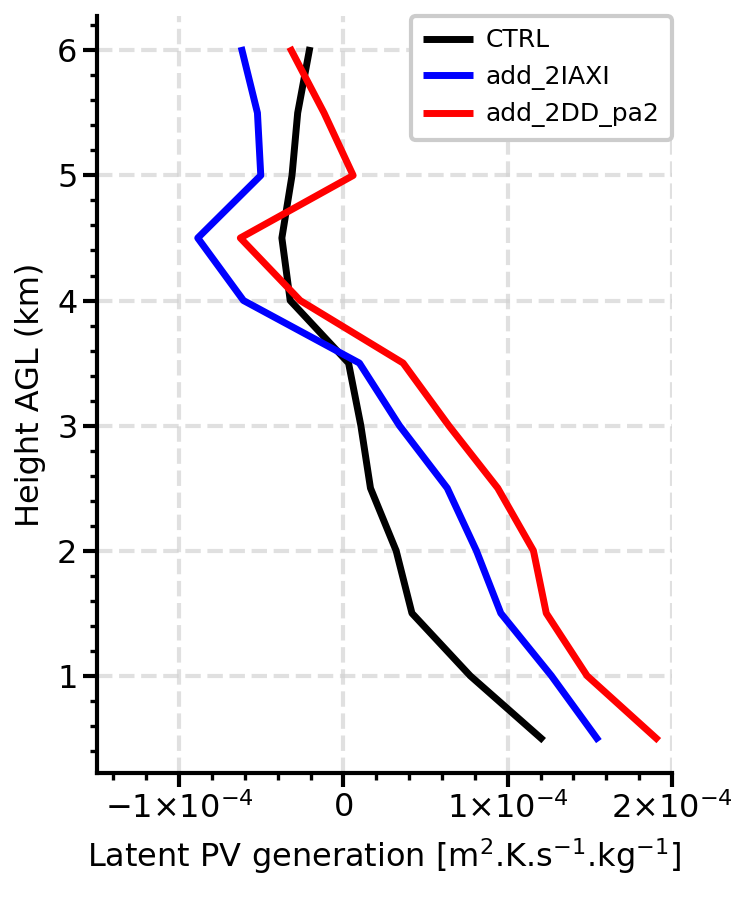

In [21]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(3.75,4.5), share=True)
am = axs[0].plot(np.nanmean(pvbudget_results['CTRL']['la_pv_z'][:,:12,:33,:],axis=(0,2,3)),z[:12]/1000, 
                 c='k', lw=2.5, label='CTRL')
am = axs[0].plot(np.nanmean(pvbudget_results['AIAXI2X']['la_pv_z'][:,:12,:33,:],axis=(0,2,3)),z[:12]/1000, 
                 c='b', lw=2.5, label='add_2IAXI')
am = axs[0].plot(np.nanmean(pvbudget_results['DD_P2F']['la_pv_z'][:,:12,:33,:],axis=(0,2,3)),z[:12]/1000, 
                 c='r', lw=2.5, label='add_2DD_pa2')
axs[0].legend(ncols=1,loc=1)
axs.format(#ylim=(1000,100),
    xlim=(-15e-5,20e-5),
           xlabel='Latent PV generation [m$^2$.K.s$^{-1}$.kg$^{-1}$]', ylabel='Height AGL (km)',
   xformatter='sci')
#plt.savefig('./pics/pvbud_latentprod_memb03_a2.png',dpi=400)
plt.show()